In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Tue Feb  3 06:26:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import files

print("Please upload the FastR_CNN_UAEpalm.pt file:")
uploaded = files.upload()

# Move the uploaded file to the desired path if it's not already there
import os
if 'yolov12_palm.pt' in uploaded:
    with open('//content/Yolov11_UAEpalm.pt', 'wb') as f:
        f.write(uploaded['Yolov11_UAEpalm.pt'])
    print("File olov11_UAEpalm.pt uploaded successfully to /content/")
else:
    print("olov11_UAEpalm.pt not found in uploaded files. Please ensure you upload the correct file.")


Please upload the FastR_CNN_UAEpalm.pt file:


Saving RF_DETR.pt to RF_DETR.pt
olov11_UAEpalm.pt not found in uploaded files. Please ensure you upload the correct file.


In [ ]:
model = YOLO("/content/RF_DETR.pt")

In [ ]:
results = model.predict("/content/drive/MyDrive/160_7_48/test/images")


image 1/48 /content/drive/MyDrive/160_7_48/test/images/111_jpg.rf.c905b2413f2e4d40cd1fc02d1cf0f39a.jpg: 320x320 164 FruitTreess, 30 Palm Treess, 235.6ms
image 2/48 /content/drive/MyDrive/160_7_48/test/images/112_jpg.rf.f6d35bd002c5a829eec42f110f04e66f.jpg: 320x320 172 FruitTreess, 5 Palm Treess, 84.8ms
image 3/48 /content/drive/MyDrive/160_7_48/test/images/116_jpg.rf.b427fe2157afad15b5b954a838f60b99.jpg: 320x320 150 FruitTreess, 2 Otherss, 77 Palm Treess, 40.1ms
image 4/48 /content/drive/MyDrive/160_7_48/test/images/130_jpg.rf.d180fad514b5bacae6d25240ee674664.jpg: 320x320 53 Palm Treess, 41.9ms
image 5/48 /content/drive/MyDrive/160_7_48/test/images/148_jpg.rf.de8b7d1c263ae3f2bcab471798a65e04.jpg: 320x320 1 Field Crops, 61.7ms
image 6/48 /content/drive/MyDrive/160_7_48/test/images/149_jpg.rf.a0d29d3751e9ed322d5d576cf456bb8b.jpg: 320x320 1 Field Crops, 74.1ms
image 7/48 /content/drive/MyDrive/160_7_48/test/images/155_jpg.rf.93cbba42e4b65902a97bdac0bda8126e.jpg: 320x320 1 Others, 43.2ms


In [ ]:
import os
import cv2
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix

# Check GPU availability
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU Detected: {torch.cuda.get_device_name(0)}")
    device = 0
else:
    print("WARNING: No GPU detected. Training will be slow on CPU.")
    device = 'cpu'

PyTorch Version: 2.9.0+cu126
GPU Detected: Tesla T4


              precision    recall  f1-score   support

 Field Crops       0.80      1.00      0.89         4
  FruitTrees       1.00      0.80      0.89         5
 GreenHouses       0.57      0.80      0.67         5
      Others       0.91      0.91      0.91        11
  Palm Trees       1.00      0.91      0.95        23

    accuracy                           0.90        48
   macro avg       0.86      0.88      0.86        48
weighted avg       0.92      0.90      0.90        48



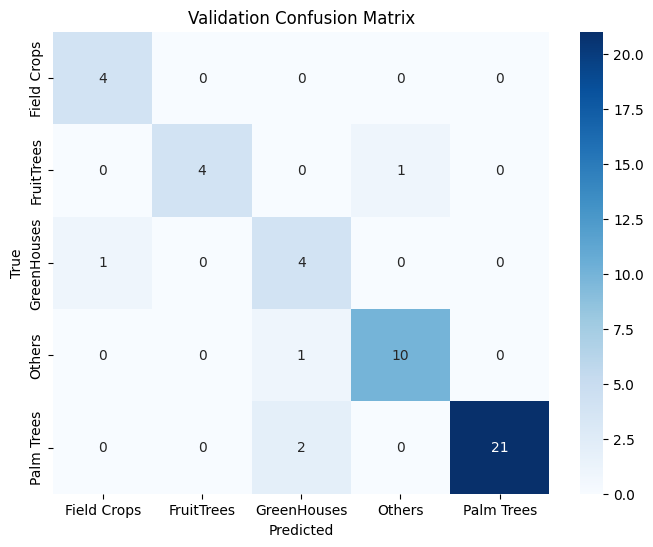

In [ ]:
val_image_dir = "/content/drive/MyDrive/160_7_48/test/images"
val_label_dir = "/content/drive/MyDrive/160_7_48/test/labels"

# Class names (EDIT if needed)
# Removed hardcoded class_names to dynamically generate them later.

y_true = []
y_pred = []

# -----------------------------------
# LOOP OVER YOLO PREDICTIONS
# -----------------------------------
for r in results:
    img_name = os.path.basename(r.path)
    lbl_path = os.path.join(val_label_dir, img_name.replace(".jpg", ".txt"))

    # -----------------------------
    # TRUE LABELS
    # -----------------------------
    true_classes = []
    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                true_classes.append(int(line.split()[0]))

    # Skip images with no GT objects
    if len(true_classes) == 0:
        continue

    # -----------------------------
    # PREDICTED LABEL (highest confidence)
    # -----------------------------
    if len(r.boxes.cls) > 0:
        confs = r.boxes.conf.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy()
        cls_pred = int(classes[np.argmax(confs)])
    else:
        # If no predictions, consider it a background/no detection
        # You might want to handle this differently based on your goal
        continue

    # -----------------------------
    # APPEND (image-level dominant class)
    # -----------------------------
    # Assuming the first true class represents the dominant class for simplicity
    y_true.append(true_classes[0])
    y_pred.append(cls_pred)

# Get all unique labels from y_true and y_pred for proper report generation
labels_present = sorted(list(np.unique(y_true + y_pred)))

# Get class names from the trained model's dictionary
class_names_dict = model.names

# Create a list of target names corresponding to the unique labels present
target_names_for_report = [class_names_dict[label] for label in labels_present]

# -----------------------------------
# CLASSIFICATION REPORT
# -----------------------------------
print(classification_report(
    y_true,
    y_pred,
    labels=labels_present, # Specify the actual labels present
    target_names=target_names_for_report,
    zero_division=0
))

# -----------------------------------
# CONFUSION MATRIX
# -----------------------------------
cm = confusion_matrix(y_true, y_pred, labels=labels_present)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names_for_report,
    yticklabels=target_names_for_report
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
import os
from collections import Counter

labels_dir = "/content/drive/MyDrive/160_7_48/test/labels"
gt_counts = Counter()

for label_file in os.listdir(labels_dir):
    if not label_file.endswith(".txt"):
        continue
    with open(os.path.join(labels_dir, label_file)) as f:
        for line in f:
            cls = int(line.split()[0])
            gt_counts[cls] += 1

# Map IDs to names
class_names = {
    0: "field_crops",
    1: "fruit_trees",
    2: "greenhouses",
    3: "other_vegetation",
    4: "palm_trees"
}

print("Ground-truth objects per class:")
for cls_id, count in gt_counts.items():
    print(f"{class_names[cls_id]}: {count}")

Ground-truth objects per class:
other_vegetation: 77
greenhouses: 31
field_crops: 37
palm_trees: 2225
fruit_trees: 411


In [ ]:
from collections import Counter
# Count detections per class
class_counts = Counter()

for r in results:
    if r.boxes is None:
        continue
    for cls in r.boxes.cls:
        class_counts[int(cls)] += 1

# Map class IDs to names
class_names = model.names

print("Detected objects per class:")
for cls_id, count in class_counts.items():
    print(f"{class_names[cls_id]}: {count}")

Detected objects per class:
FruitTrees: 651
Palm Trees: 3633
Others: 266
Field Crops: 56
GreenHouses: 32


In [ ]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

y_true = []
y_pred = []

for r in results:
    img_path = r.path
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")

    # Ground truth: most frequent GT class in image
    if os.path.exists(label_path):
        with open(label_path) as f:
            gt_classes = [int(line.split()[0]) for line in f.readlines()]
        y_true.append(max(set(gt_classes), key=gt_classes.count))
    else:
        y_true.append(-1)

    # Prediction: most confident detected class
    if len(r.boxes.cls) > 0:
        y_pred.append(int(r.boxes.cls[0]))
    else:
        y_pred.append(-1)


In [ ]:
kappa = cohen_kappa_score(y_true, y_pred)
print(f"Cohen’s Kappa: {kappa:.4f}")


Cohen’s Kappa: 0.7254



image 1/1 /content/65.jpg: 320x320 121 Palm Treess, 41.0ms
Speed: 1.5ms preprocess, 41.0ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /content/runs/detect/predict


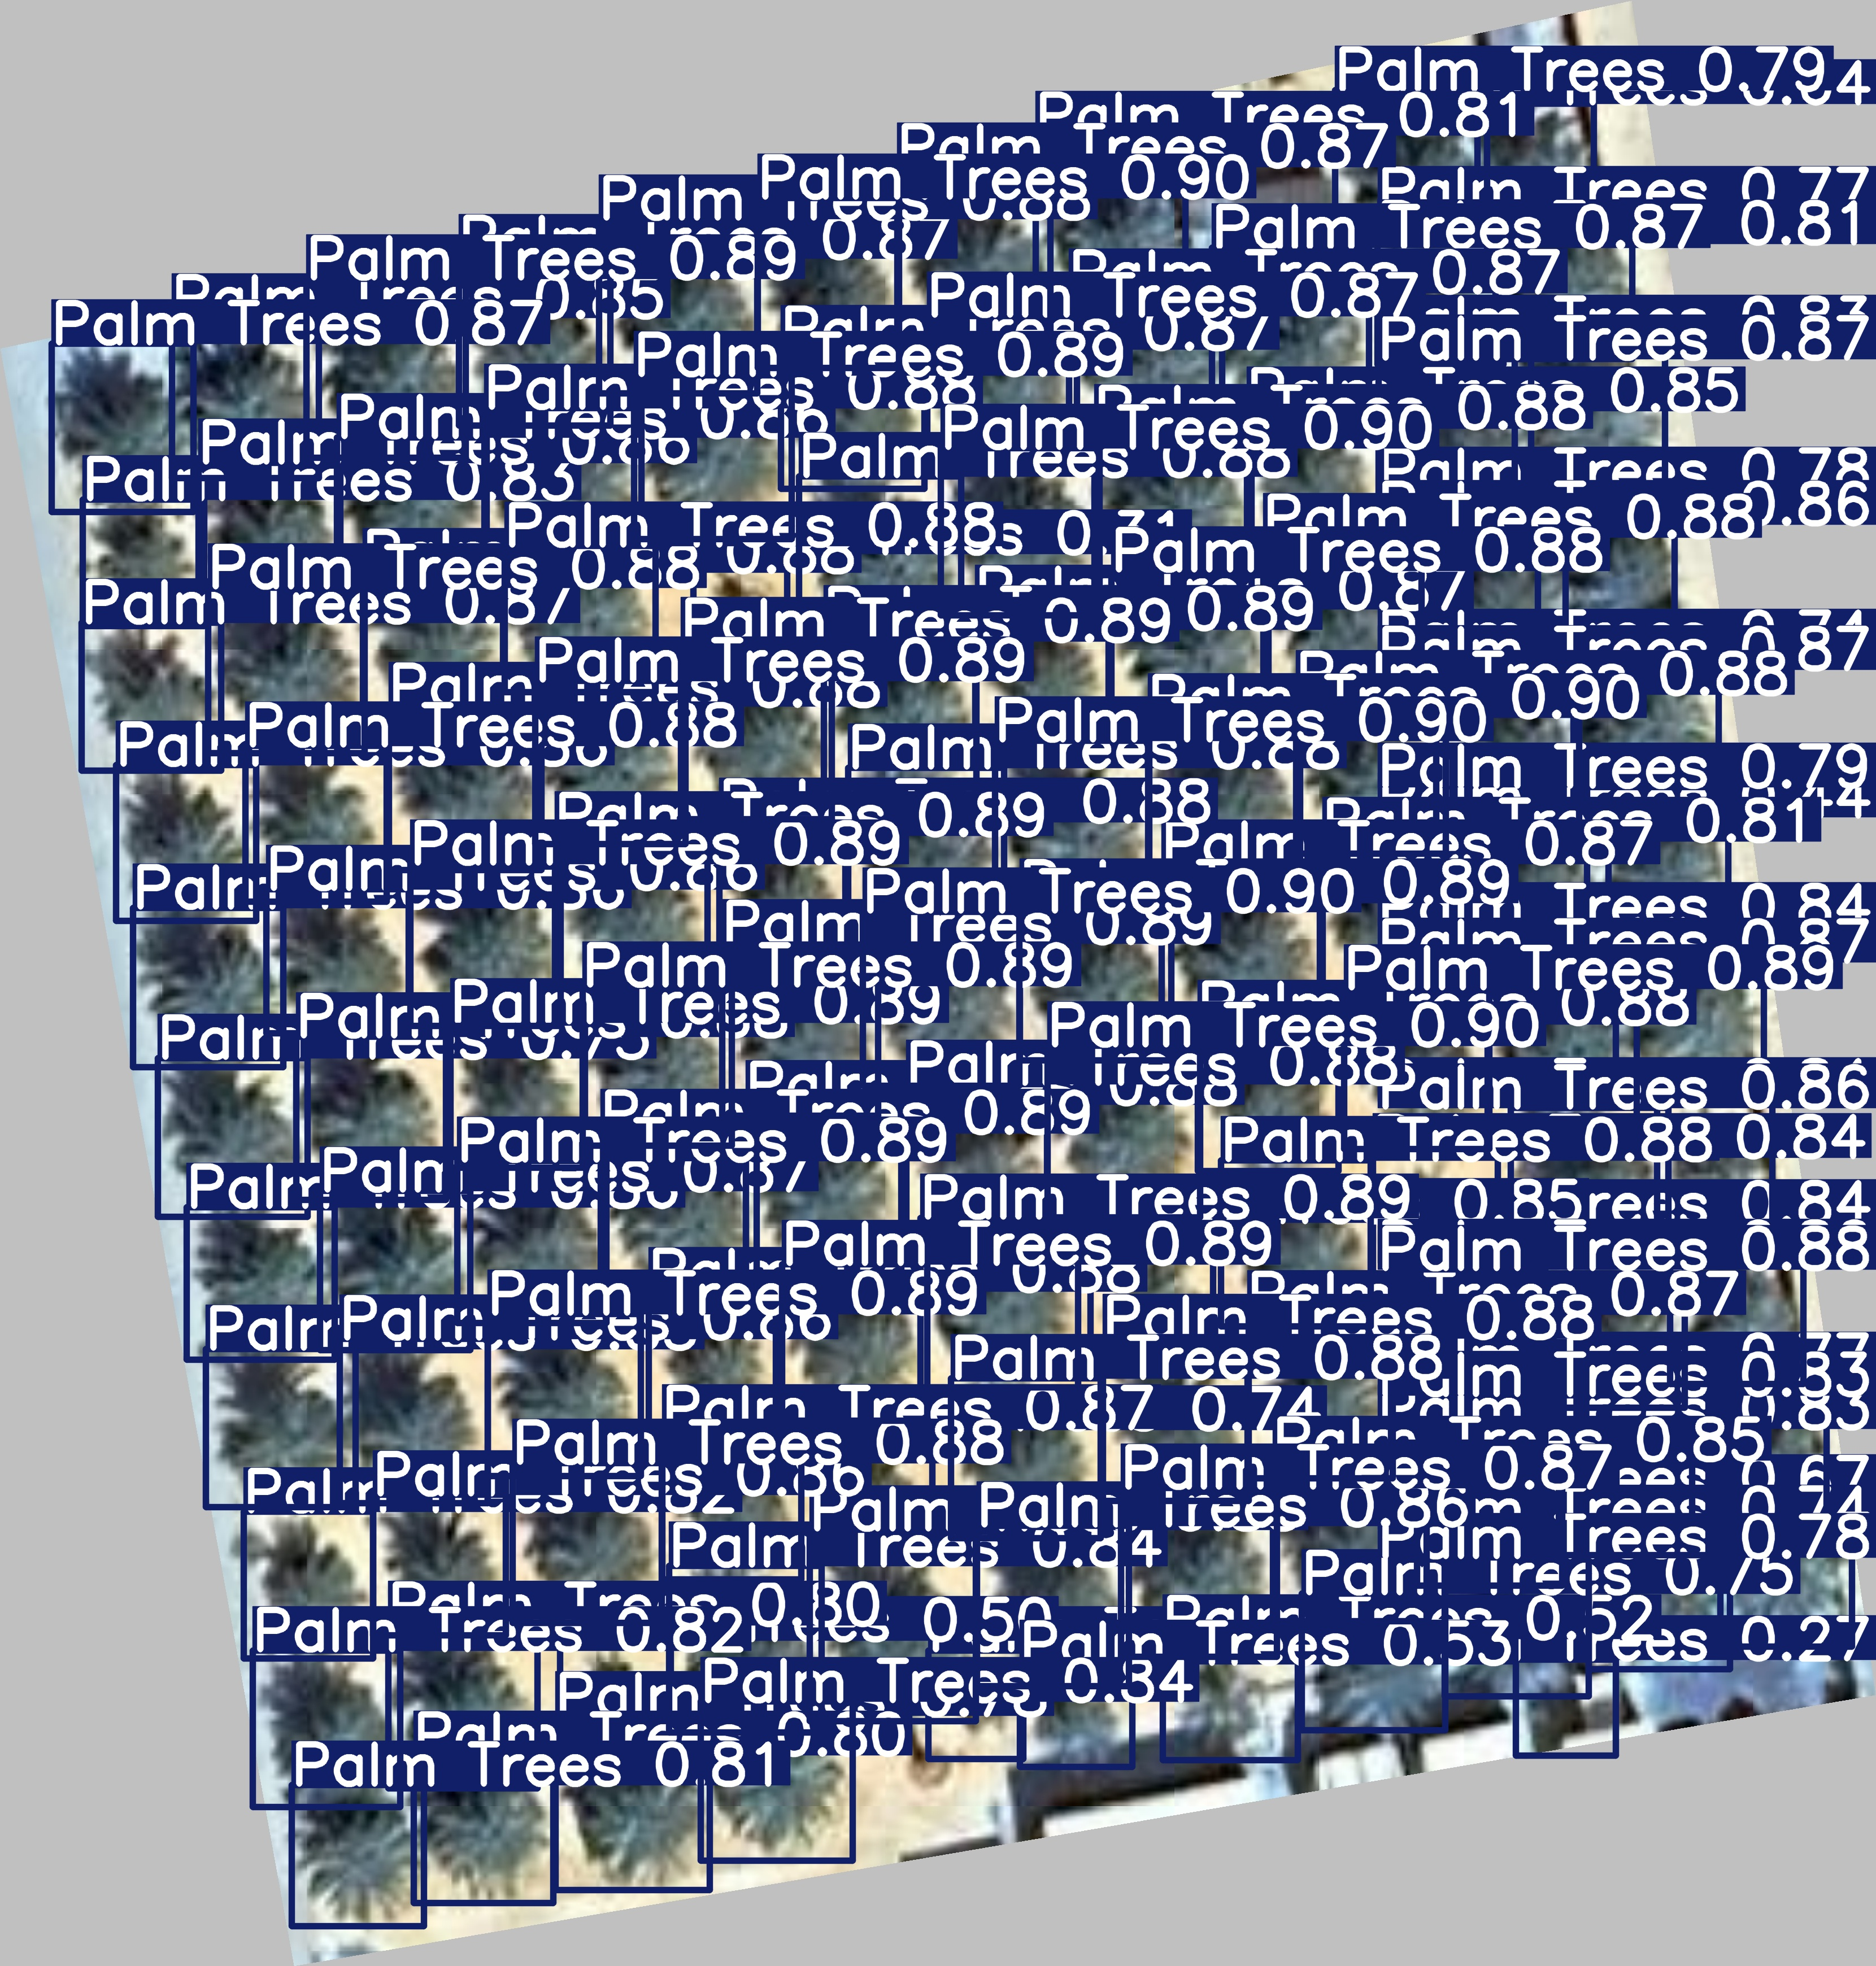

In [ ]:
image = model.predict('/content/65.jpg', save=True)
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/predict/65.jpg', width=600)

In [ ]:
# Class ID for date palms (update if different)
PALM_CLASS_ID = 4   # example

detections = image[0].boxes
palm_count = (detections.cls == PALM_CLASS_ID).sum().item()

print(f"Number of date palm trees detected: {palm_count}")

Number of date palm trees detected: 121


In [ ]:
results = image[0]
boxes = results.boxes

if boxes is None or len(boxes) == 0:
    print("No trees detected.")
    exit()

In [ ]:
sorted_indices = boxes.xyxy[:, 0].argsort()

tree_id = 1

In [ ]:
boxes.xyxy[:, 0].argsort()

tensor([ 61,  60,  88,  72,  73, 108,  80,  75,  71,  76,  35,  92,  36,  93,  67,  95,  28,  21,  57,  68,  64,  40,  74,  98,  37,  18,  99,  20,  15,  52,  41,   8,  33,  30,   7,  22, 104, 116,   9,  27,  19,  16,  46,  51,  86,  14, 118,  83,  34,  10,  42,   4,  55,   6,  29,  77,  17, 110,  24,   0,  48,  32,
         13,  53, 119,   5,  25,  47,  70,   1, 114,  12,  96,   2,  56,  79,  39,  44,  26,  62,   3,  49, 115,  38,  63,  31,  78,  50,  43,  81,  23, 107,  97, 101,  11,  82,  94,  59,  45,  91,  65,  54, 102, 117, 113,  58, 106,  66,  89, 120, 103,  69,  90, 109, 100, 111,  87,  84,  85, 105, 112],
       device='cuda:0')

In [ ]:
boxes.xyxy[:, 1].argsort()

tensor([101, 113,  96,  48,   4, 106,  27,  94,  63,  52,  21,  56,  53,  80,  89,  61,  55,  59,  16,  41,  78,  39,  68,   5,  71,  29, 103,  88,  65,  43,  33, 118,  26,  40,  35,  47,  60,  17,  14, 109,  54,   7,  23,  37,   3,   1,  36,  72,  24, 100, 117,  34,  22,  97,  18,  49,  67,  12,  73,   0,  87,  10,
         58,   9,  11,  20,  38,  28,   2, 108,  32,  84,  42,  66,  19,  82,  31,  15,  57,  75,  13,  79,  85,  69,   6,  45,  46,   8,  50,  44,  64,  76, 105,  25,  90,  91,  51, 110,  81,  30,  62,  74, 112,  92,  70, 111,  77, 102,  86, 107,  98, 115, 116,  93, 119, 120, 114,  83, 104,  99,  95],
       device='cuda:0')

In [ ]:
from collections import Counter

class_counts = Counter()

for box in boxes:
    cls = int(box.cls[0])
    class_counts[cls] += 1

print(class_counts)


Counter({4: 121})


In [ ]:
# Get the original image from the 'results' object as a numpy array
# and make a copy to draw on it.
drawn_image = results.orig_img.copy()

for idx in sorted_indices:
    box = boxes[idx]
    cls = int(box.cls[0])

    if cls != PALM_CLASS_ID:
        continue

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # Draw bounding box on drawn_image
    cv2.rectangle(drawn_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Label
    label = f"Tree-{tree_id}"

    cv2.putText(
        drawn_image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2,
        cv2.LINE_AA
    )

    tree_id += 1

In [ ]:
output_file_path = '/content/runs/detect/predict/65_numbered.jpg'
cv2.imwrite(output_file_path, drawn_image)

print(f"✅ Numbered image saved as: {output_file_path}")
print(f"🌴 Total trees counted: {tree_id - 1}")

✅ Numbered image saved as: /content/runs/detect/predict/65_numbered.jpg
🌴 Total trees counted: 121


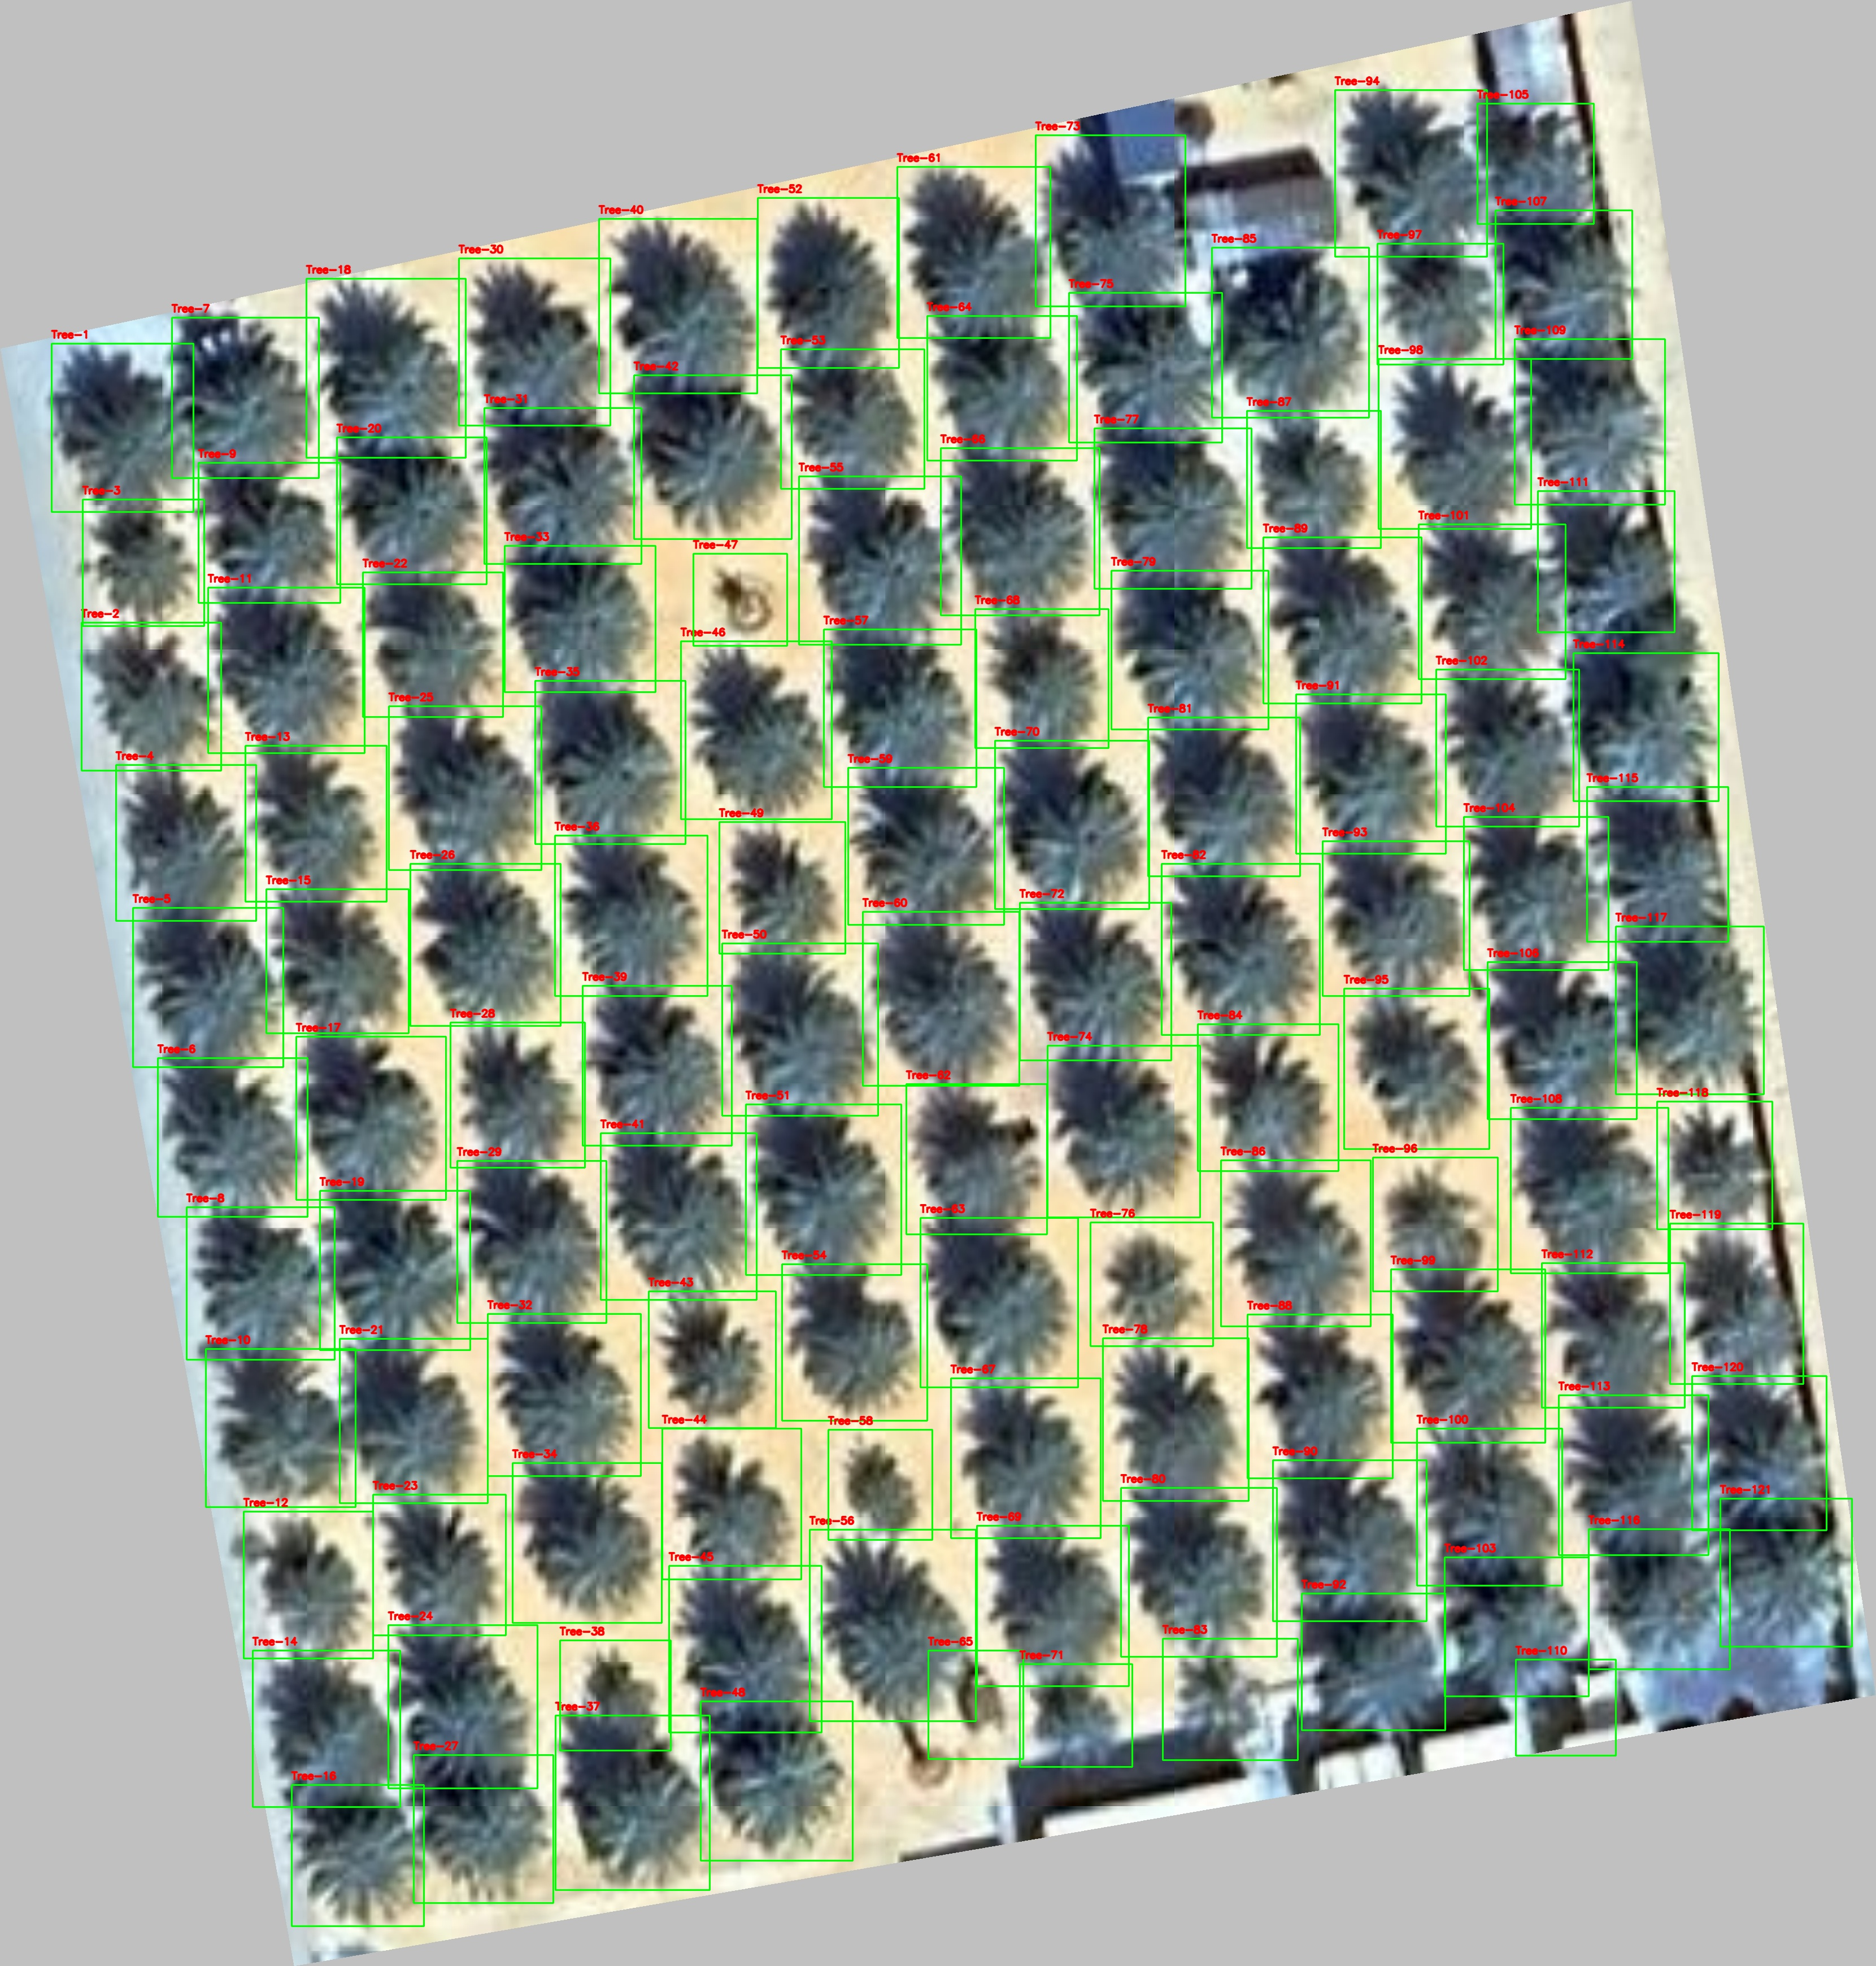

In [ ]:
IPyImage(filename=f'/content/runs/detect/predict/65_numbered.jpg', width=600)